In [24]:
import tensorflow as tf 
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential  # itwill create layers in sequence
from tensorflow.keras.layers import Dense, Flatten  # it will flatten the image into 1D array and dense is used to create fully connected layers
from tensorflow.keras.utils import to_categorical  # it will convert the labels into one-hot encoding

import matplotlib.pyplot as plt 
import numpy as np 
import warnings 
warnings.filterwarnings('ignore')  # to ignore the warnings

np.random.seed(42)  # to make the results reproducible

In [25]:
(x_train , y_train) , (x_test , y_test) = mnist.load_data()

In [26]:
x_train.shape

(60000, 28, 28)

In [27]:
y_train.shape

(60000,)

In [28]:
x_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

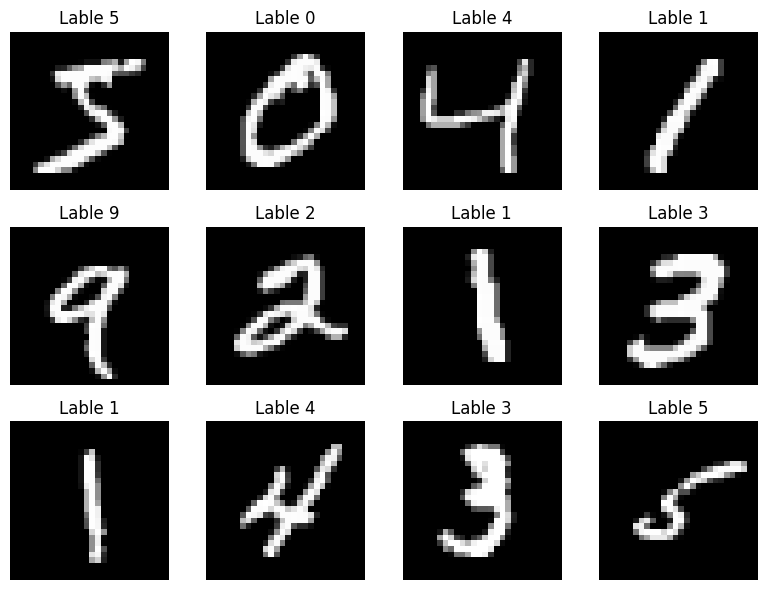

In [29]:
plt.figure(figsize = (8,6))

for i in range(12):
    plt.subplot(3 , 4 , i+1)
    plt.imshow(x_train[i], cmap = "gray")
    plt.title(f"Lable {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [30]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [31]:
# values of pixels are from 0-255

# we will bring the values b/w 0 to 1 
# we will do scaling >> normalistion >> x-xmin // xmax - xmin 
# simply divide the values by 255.

In [32]:
x_train = x_train / 255.0 
x_test = x_test / 255.0

In [33]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [34]:
y_train_cat = to_categorical(y_train , 10)
y_test_cat = to_categorical(y_test , 10)

In [35]:
for i in range(12):
    print(y_train_cat[i])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [36]:
#  FIRST ANN MODEL 

In [37]:
model = Sequential([

    # converting the 28*28 image into 1D array of 784 features
    Flatten(input_shape = (28,28)), # Flattening the image >> 784 features 

    Dense(64 , activation = "relu"), # first hidden layer with 64 neurons and relu activation function
    Dense(128 , activation = "relu"), # second hidden layer with 128 neurons and relu activation function
    Dense(10 , activation = "Softmax") # output layer with 10 neurons and softmax activation function


])

In [38]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 784)               0         
                                                                 
 dense_6 (Dense)             (None, 64)                50240     
                                                                 
 dense_7 (Dense)             (None, 128)               8320      
                                                                 
 dense_8 (Dense)             (None, 10)                1290      
                                                                 
Total params: 59850 (233.79 KB)
Trainable params: 59850 (233.79 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [39]:
model.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])

In [40]:
model

Training Data

      # ↓

Divide into batches of 100
      
      # ↓

Train on all batches = 1 epoch
      
      # ↓

Repeat 15 times
      
      # ↓

Check performance on validation data
      
      # ↓

Store results in history

In [46]:
history = model.fit(x_train , y_train_cat , epochs = 15 , batch_size = 100 , validation_split = 0.1 , verbose = 2 )


# “Train the model using training data for 15 rounds, process 100 samples at a time, keep 10% data for validation, and show training results neatly.”

Epoch 1/15
540/540 - 1s - loss: 0.0147 - accuracy: 0.9954 - val_loss: 0.0969 - val_accuracy: 0.9795 - 1s/epoch - 2ms/step
Epoch 2/15
540/540 - 1s - loss: 0.0136 - accuracy: 0.9959 - val_loss: 0.1046 - val_accuracy: 0.9755 - 1s/epoch - 2ms/step
Epoch 3/15
540/540 - 1s - loss: 0.0134 - accuracy: 0.9958 - val_loss: 0.1047 - val_accuracy: 0.9763 - 1s/epoch - 3ms/step
Epoch 4/15
540/540 - 1s - loss: 0.0134 - accuracy: 0.9956 - val_loss: 0.1064 - val_accuracy: 0.9778 - 1s/epoch - 3ms/step
Epoch 5/15
540/540 - 1s - loss: 0.0082 - accuracy: 0.9974 - val_loss: 0.1132 - val_accuracy: 0.9780 - 1s/epoch - 3ms/step
Epoch 6/15
540/540 - 2s - loss: 0.0128 - accuracy: 0.9956 - val_loss: 0.1075 - val_accuracy: 0.9780 - 2s/epoch - 3ms/step
Epoch 7/15
540/540 - 1s - loss: 0.0081 - accuracy: 0.9974 - val_loss: 0.1005 - val_accuracy: 0.9820 - 1s/epoch - 2ms/step
Epoch 8/15
540/540 - 1s - loss: 0.0115 - accuracy: 0.9960 - val_loss: 0.1112 - val_accuracy: 0.9790 - 1s/epoch - 2ms/step
Epoch 9/15
540/540 - 1s 

In [47]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [49]:
history.history["accuracy"]

[0.9953888654708862,
 0.995888888835907,
 0.9958148002624512,
 0.9956481456756592,
 0.9973888993263245,
 0.9956481456756592,
 0.99742591381073,
 0.9960370659828186,
 0.9970740675926208,
 0.9975000023841858,
 0.9972777962684631,
 0.9984074234962463,
 0.9950000047683716,
 0.998629629611969,
 0.9977777600288391]

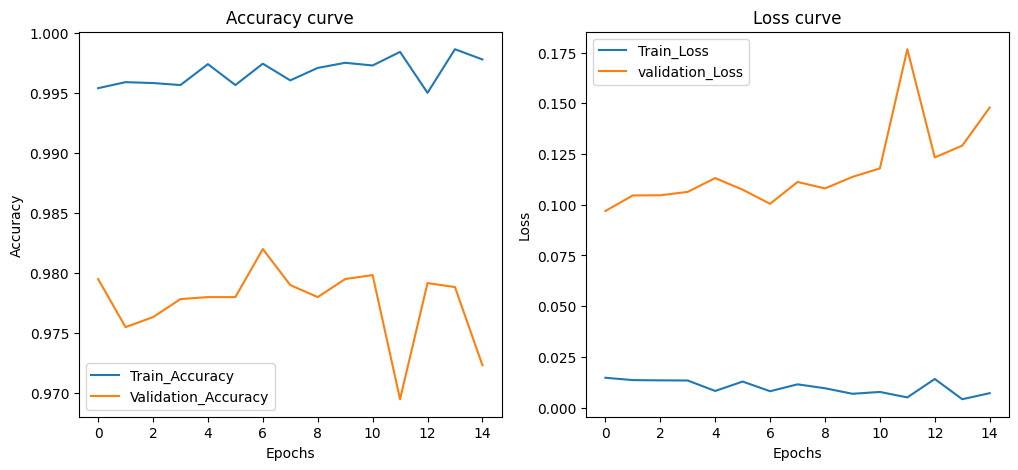

In [53]:
plt.figure(figsize = (12,5))

# accuracy 
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label = "Train_Accuracy")
plt.plot(history.history['val_accuracy'], label = "Validation_Accuracy")
plt.title("Accuracy curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label = "Train_Loss")
plt.plot(history.history["val_loss"], label = "validation_Loss")
plt.title("Loss curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

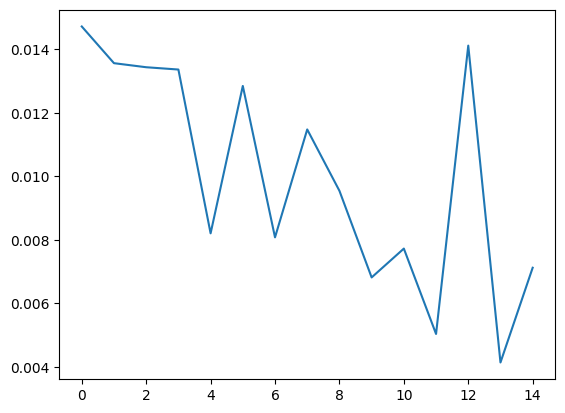

In [50]:
plt.plot(history.history['loss'])

In [55]:
test_loss, test_acc = model.evaluate(x_test , y_test_cat, verbose = 2)

313/313 - 0s - loss: 0.1516 - accuracy: 0.9710 - 427ms/epoch - 1ms/step


In [56]:
test_loss

0.15155556797981262

In [57]:
test_acc

0.9710000157356262

In [58]:
y_pred_probs = model.predict(x_test)

313/313 [==============================] - 1s 1ms/step


In [59]:
y_pred_probs

array([[3.0001422e-14, 1.1545096e-13, 3.0783546e-11, ..., 9.9999774e-01,
        2.9431124e-11, 2.2734207e-06],
       [1.8562138e-19, 8.2261749e-07, 9.9999917e-01, ..., 1.3976913e-25,
        1.8460644e-14, 9.9779989e-25],
       [1.2601918e-09, 9.9999285e-01, 2.5098061e-06, ..., 4.8496378e-07,
        3.0949020e-06, 6.7104128e-11],
       ...,
       [1.4374696e-23, 3.1556028e-19, 5.8294668e-20, ..., 7.4582962e-15,
        1.6021752e-13, 2.3385072e-10],
       [4.3512777e-17, 2.3463003e-24, 1.1499496e-21, ..., 4.3775851e-16,
        5.0929291e-08, 1.7743843e-20],
       [2.3055990e-19, 8.7208111e-27, 5.8688038e-20, ..., 3.2024900e-31,
        1.0627705e-22, 3.0611638e-27]], dtype=float32)

In [60]:
y_pred_class = np.argmax(y_pred_probs , axis = 1)
y_pred_class

array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

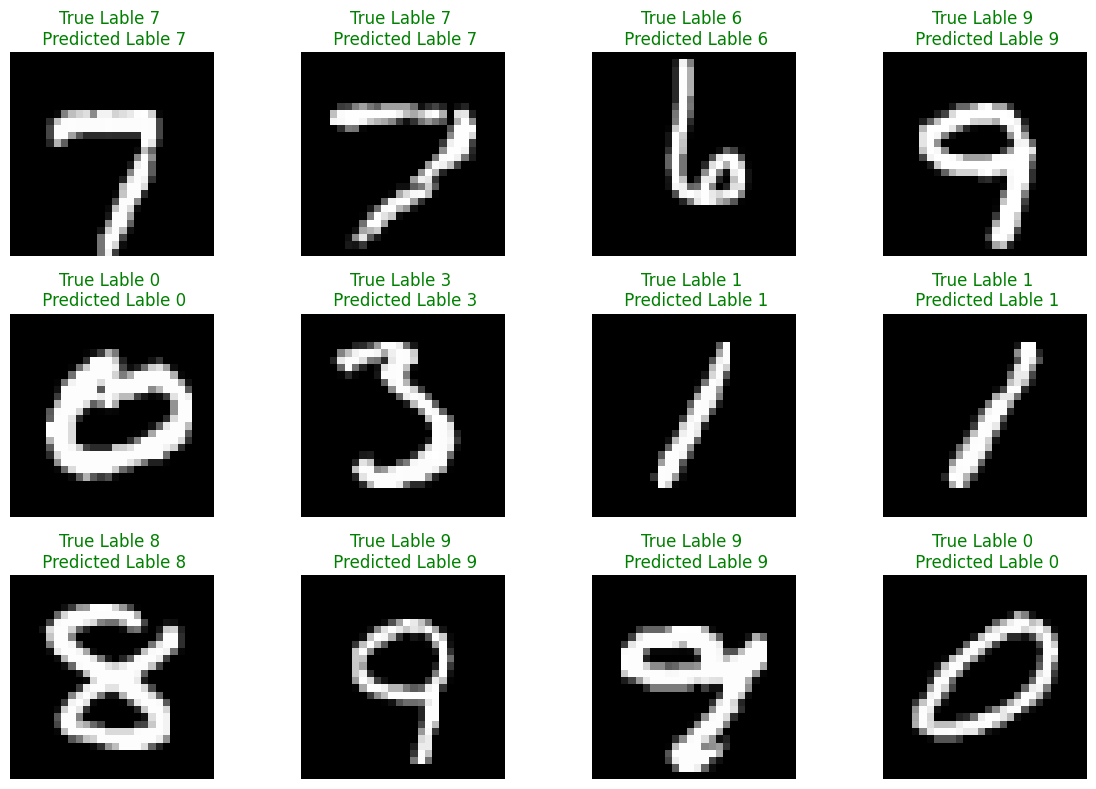

In [63]:
plt.figure(figsize = (12,8))
for i , idx in enumerate(np.random.choice(len(x_test) , 12 , replace = False)):
    plt.subplot(3 , 4 , i+1)
    plt.imshow(x_test[idx], cmap = "gray")
    color = "green" if y_test[idx] == y_pred_class[idx] else "red"
    plt.title(f"True Lable {y_test[idx]} \n Predicted Lable {y_pred_class[idx]}", color = color)
    plt.axis("off")

plt.tight_layout()
plt.show()

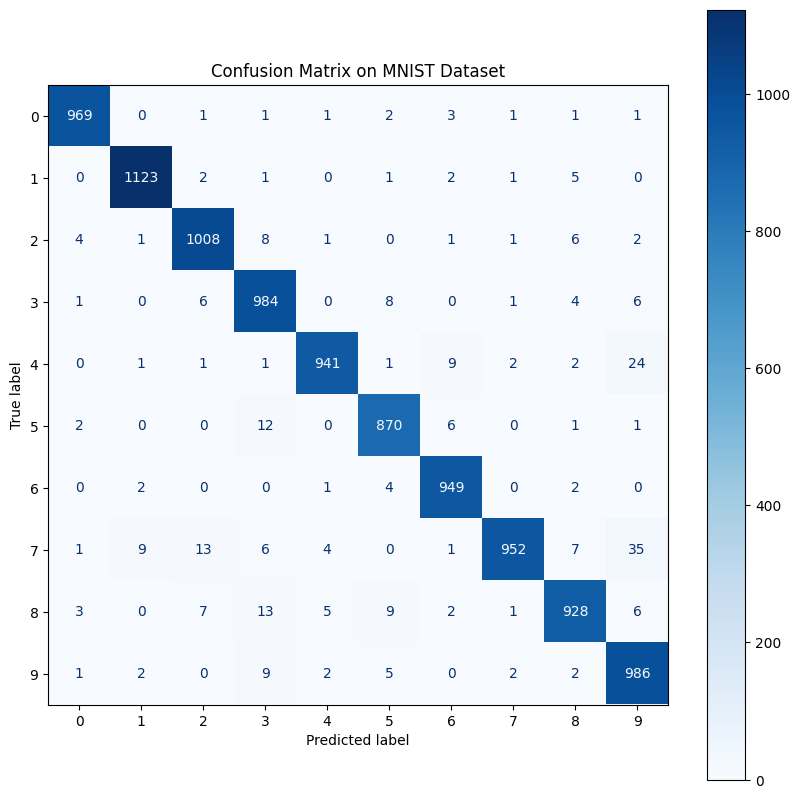

In [64]:
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay 

cm = confusion_matrix(y_test , y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
fig,ax = plt.subplots(figsize = (10,10))
disp.plot(ax = ax , cmap = "Blues")
plt.title("Confusion Matrix on MNIST Dataset")

plt.show()